In [1]:
#| default_exp _trainer

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#| export
import torch
import matplotlib.pyplot as plt
from dreamer4._core import build_tiny_pinpad_dataset, make_tiny_dataloader, build_pinpad_datasets_for_trainers
from dreamer4.dreamer4 import VideoTokenizer, DynamicsWorldModel
from dreamer4.trainers import VideoTokenizerTrainer, SimTrainer, cycle, BehaviorCloneTrainer
import random

/home/james/workspace/dreamer4/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pads {'3', '1', '2'} target ('1', '2', '3')

pads {'3', '1', '2'} target ('1', '2', '3')



In [4]:
CPU = False
neps = 1
device = 'cuda' if not CPU else 'cpu'
dataset, env = build_tiny_pinpad_dataset(device=device, episode_length=100, n=neps)

pads {'3', '1', '2'} target ('1', '2', '3')

Built tiny PinPad dataset with 1 videos of shape torch.Size([3, 100, 64, 64]) - (c, t, h, w). Success rate 100.0%


In [5]:
# 1) Build datasets
tok_ds, bc_ds, env = build_pinpad_datasets_for_trainers(
    n_episodes=200,
    episode_length=100,
    tok_window=16,
    device='cpu',
    use_motion_planner=True
)


pads {'3', '1', '2'} target ('1', '2', '3')

pads {'3', '1', '2'} target ('1', '2', '3')



In [6]:
import torch
import matplotlib.pyplot as plt

def get_video_from_sample(sample):
    """Return a (C,T,H,W) or (T,C,H,W) tensor from dict/tuple/tensor samples."""
    if isinstance(sample, dict):
        v = sample.get("video", next((x for x in sample.values() if torch.is_tensor(x)), None))
    elif isinstance(sample, (list, tuple)):
        # common case: TensorDataset(videos) -> (video,)
        v = sample[0]
    else:
        v = sample
    if not torch.is_tensor(v):
        raise TypeError(f"Couldn't find a tensor video in sample of type {type(sample)}")
    return v

def canonicalize_cthw(v):
    """Ensure (C,T,H,W); convert dtype/range for visibility."""
    if v.ndim != 4:
        raise ValueError(f"Expected 4D video, got shape {tuple(v.shape)}")
    # If first dim isn't channels, assume (T,C,H,W) and permute
    if v.shape[0] not in (1,3):
        v = v.permute(1,0,2,3).contiguous()  # (T,C,H,W) -> (C,T,H,W)
    # Make float in [0,1] for viewing
    if v.dtype.is_floating_point:
        # if it looks zero-centered, de-normalize (heuristic)
        if v.min() < 0:
            v = (v * 0.5) + 0.5
        v = v.clamp(0,1)
    else:
        v = v.float() / 255.0
    return v

def peek_video(sample, title="sample", t=0):
    v = get_video_from_sample(sample)
    print(f"{title} raw:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    v = canonicalize_cthw(v)
    C,T,H,W = v.shape
    img = v[:, min(t,T-1)].permute(1,2,0).cpu().numpy()
    print(f"{title} canonical:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.title(f"{title} t={min(t,T-1)}"); plt.axis("off"); plt.show()
    return v


tok_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: -1.0 1.0
tok_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


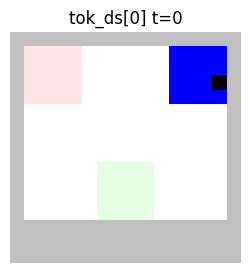

bc_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: -1.0 1.0
bc_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


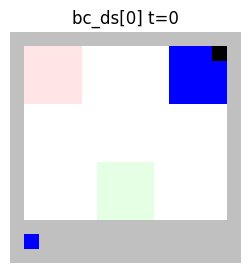

In [7]:

# Use on both datasets:
v_tok = peek_video(tok_ds[0], title="tok_ds[0]")
v_bc  = peek_video(bc_ds[0],  title="bc_ds[0]")


In [8]:
## DEBUG MEMORY ##

import torch
import gc
import psutil

def format_bytes(size):
    power = 2**10
    n = 0
    power_labels = {0 : '', 1: 'K', 2: 'M', 3: 'G', 4: 'T'}
    while size > power:
        size /= power
        n += 1
    return f"{size:.2f} {power_labels[n]}B"

def audit_gpu_memory():
    """
    Prints a breakdown of what is currently on the GPU.
    Safely handles torch.compile Symbolic/FakeTensors.
    """
    if not torch.cuda.is_available():
        print("CUDA is not available.")
        return

    print("\n--- GPU MEMORY AUDIT ---")
    
    # 1. Global Stats
    try:
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        print(f"Total Allocated (Tensors): {format_bytes(allocated)}")
        print(f"Total Reserved (Caching Allocator): {format_bytes(reserved)}")
    except Exception as e:
        print(f"Could not get global stats: {e}")
    
    # 2. Iterate through all Python objects to find GPU Tensors
    tensors = []
    for obj in gc.get_objects():
        try:
            # Check if it's a tensor
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                # FILTER: Skip Symbolic/Fake tensors (used by torch.compile)
                # If it doesn't have a concrete device index, it's not real VRAM.
                if obj.device.type != 'cuda':
                    continue
                
                # FILTER: Skip if we can't get a concrete integer size
                # (Symbolic tensors return SymInts for nelement, which crash int() conversion)
                if hasattr(obj, "is_meta") and obj.is_meta:
                    continue
                    
                tensors.append(obj)
        except Exception:
            # If touching the object crashes (common with some internal PyTorch objects), skip it
            pass

    print(f"\nFound {len(tensors)} discrete tensor objects on GPU.")
    
    # 3. Group by Shape/Size to identify patterns
    tensor_stats = {}
    for t in tensors:
        try:
            # Safely get size. If this crashes or returns a symbol, skip.
            numel = t.nelement()
            elem_size = t.element_size()
            
            # Force conversion to python int to catch symbols early
            total_bytes = int(numel) * int(elem_size)
            
            shape_str = str(tuple(t.shape))
            if shape_str not in tensor_stats:
                tensor_stats[shape_str] = {"count": 0, "size": 0}
            
            tensor_stats[shape_str]["count"] += 1
            tensor_stats[shape_str]["size"] += total_bytes
        except Exception:
            continue

    # 4. Print the "Top 5" Memory Hogs
    print("\nTOP 5 TENSOR GROUPS BY MEMORY:")
    
    # Now sorting is safe because 'size' is guaranteed to be a real python int
    sorted_stats = sorted(tensor_stats.items(), key=lambda x: x[1]['size'], reverse=True)[:5]
    
    for shape, stats in sorted_stats:
        print(f"  Shape {shape}: {stats['count']} tensors | Total Size: {format_bytes(stats['size'])}")

    print("-" * 30)

# Create tokenizer and dynamics models and associated training

Using device: cuda
Dataset ready. Samples: 17000
Overwriting latent parameter sizes for simplified tokenizer.

Starting Sanity Train (500 steps)...
Step 0: Loss = 2.0492
Step 10: Loss = 0.1271
Step 20: Loss = 0.0940
Step 30: Loss = 0.0705
Step 40: Loss = 0.0524
Step 50: Loss = 0.0375
Step 60: Loss = 0.0260
Step 70: Loss = 0.0225
Step 80: Loss = 0.0177
Step 90: Loss = 0.0154
Step 100: Loss = 0.0128
Step 110: Loss = 0.0119
Step 120: Loss = 0.0092
Step 130: Loss = 0.0083
Step 140: Loss = 0.0085
Step 150: Loss = 0.0071
Step 160: Loss = 0.0064
Step 170: Loss = 0.0059
Step 180: Loss = 0.0061
Step 190: Loss = 0.0055
Step 200: Loss = 0.0044
Step 210: Loss = 0.0041
Step 220: Loss = 0.0037
Step 230: Loss = 0.0044
Step 240: Loss = 0.0036
Step 250: Loss = 0.0033
Step 260: Loss = 0.0027
Step 270: Loss = 0.0026
Step 280: Loss = 0.0027
Step 290: Loss = 0.0025
Step 300: Loss = 0.0021
Step 310: Loss = 0.0020
Step 320: Loss = 0.0020
Step 330: Loss = 0.0020
Step 340: Loss = 0.0022
Step 350: Loss = 0.0017

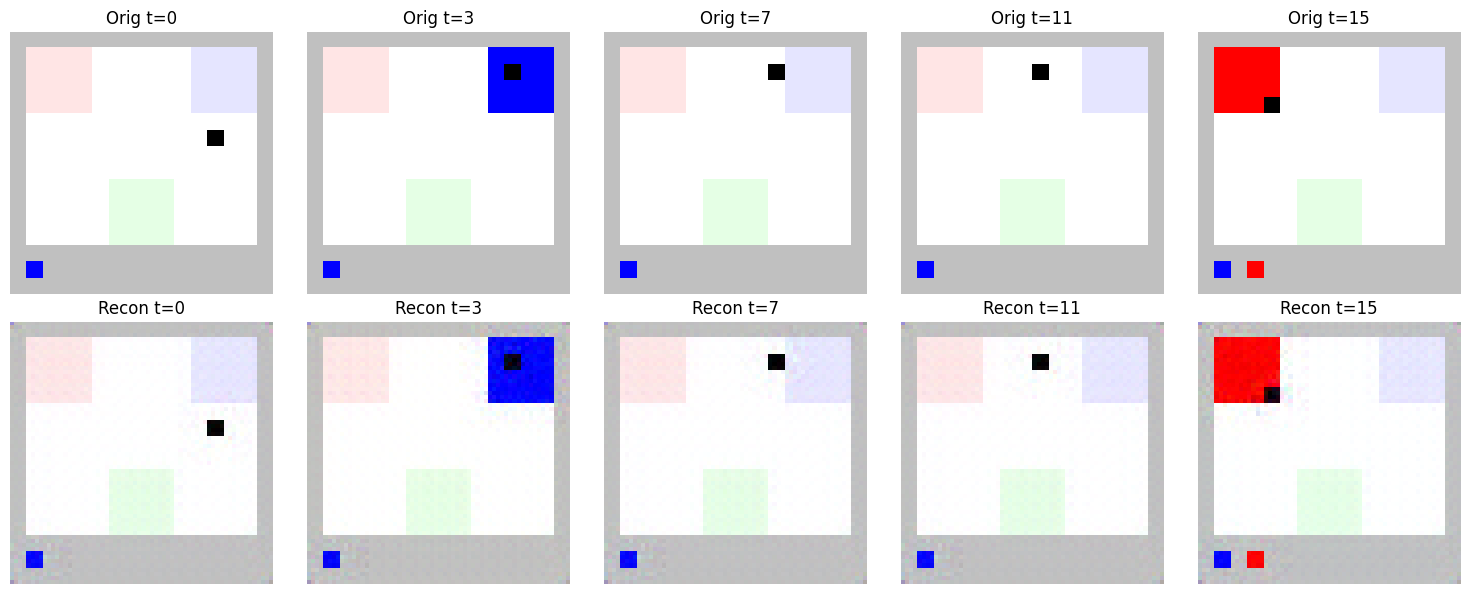

In [9]:
dim, dim_latent, num_latent_tokens, num_spatial_tokens = 256, 256, 256, 256
d=2
encoder_depth, decoder_depth, dynamics_depth = d, d, d
time_block_every=d
lpips_loss_weight=0.2 # default 
decor_auxx_loss_weight=0.1 # default
use_time_rnn = False # don't include an RNN

batch_size = 8 #16
num_train_steps=1000

accelerate_kwargs={"mixed_precision": "bf16"}
token_uses_time_block = True; time_block_every = d if token_uses_time_block else 1000

if SIMPLE_TOKENIZER:=False:
    # Tokenizer debug config suggested by gemini3 pro
    tk = VideoTokenizer(
        dim=dim,                  # Massive increase from 64/128 (Better feature capture)
        dim_latent=dim_latent,           # Larger bottleneck capacity
        patch_size=4,             # Keep this small
        num_latent_tokens=num_latent_tokens,    # CRITICAL: Keep this matched to patches (16x16)
        encoder_depth=encoder_depth,          # Deeper is better for reasoning about features
        decoder_depth=decoder_depth,
        time_block_every=time_block_every,       # More temporal blocks for video
        lpips_loss_weight=lpips_loss_weight,    # Strong perceptual signal
        per_image_patch_mask_prob=(0.0, 0.0),  # No masking during debugging
        decor_auxx_loss_weight = decor_auxx_loss_weight,
    ).to(device)

    from torch.optim import AdamW
    # 2) Train tokenizer (VideoTokenizerTrainer expects a TensorDataset and uses [0])
    tok_tr = VideoTokenizerTrainer(tk, tok_ds, batch_size=batch_size, num_train_steps=num_train_steps,
                                weight_decay=0,
                                optim_klass=AdamW,
                                #    learning_rate=1e-3,
                                accelerate_kwargs=accelerate_kwargs,)
    tok_tr(num_train_step=1000)
else:
    from dreamer4._core import DataLoader
    from torch.optim import AdamW
    import numpy as np

    n_train_steps=500
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # A. Build Dataset

    from dreamer4._tokenizer import SimpleConvTokenizer
    dl = DataLoader(tok_ds, batch_size=16, shuffle=True)
    print(f"Dataset ready. Samples: {len(tok_ds)}")

    # B. Initialize Model
    tk = SimpleConvTokenizer(
        dim=64, 
        dim_latent=dim_latent, 
        down_steps=2,  # 16 tokens (4x4 grid)
        image_size=64,
    ).to(device)

    print(f"Overwriting latent parameter sizes for simplified tokenizer.")
    num_spatial_tokens = tk.num_latent_tokens
    num_latent_tokens = tk.num_latent_tokens

    optimizer = AdamW(tk.parameters(), lr=1e-3)

    # C. Quick Training Loop (Proof of Life)
    print(f"\nStarting Sanity Train ({n_train_steps} steps)...")
    tk.train()

    losses = []

    iterator = iter(dl)
    for i in range(n_train_steps):
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(dl)
            batch = next(iterator)
            
        video = batch.to(device) # (B, C, T, H, W)
        
        loss = tk(video)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        if i % 10 == 0:
            print(f"Step {i}: Loss = {loss.item():.4f}")

    # D. Visualization
    print("\nVisualizing Result...")
    tk.eval()

    # Get a fresh sample
    sample = next(iter(dl)).to(device)
    with torch.no_grad():
        latents = tk.encode(sample)
        recon = tk.decode(latents)

    # Pick first batch item, 5 evenly spaced frames
    idx = 0
    t_indices = np.linspace(0, sample.shape[2]-1, 5, dtype=int)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i, t in enumerate(t_indices):
        # Original (Top)
        orig = sample[idx, :, t].permute(1,2,0).cpu().numpy()
        orig = (orig + 1) / 2 # [-1, 1] -> [0, 1]
        
        # Recon (Bottom)
        rec = recon[idx, :, t].permute(1,2,0).cpu().numpy()
        rec = (rec + 1) / 2
        
        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].set_title(f"Orig t={t}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(np.clip(rec, 0, 1))
        axes[1, i].set_title(f"Recon t={t}")
        axes[1, i].axis('off')
        
        # Check specific pixel ranges
        if i == 0:
            print(f"Recon Range: min={rec.min():.2f}, max={rec.max():.2f}")

    plt.tight_layout()
    plt.show()

# dynamics = DynamicsWorldModel(
#     video_tokenizer=tk,
#     dim=dim,
#     dim_latent=dim_latent,
#     max_steps=64,
#     num_tasks=1,
#     num_latent_tokens=num_latent_tokens,          # match tokenizer
#     num_spatial_tokens=num_spatial_tokens,         # was 2 (too tiny), then 8 not big enough to track movement
#     depth=dynamics_depth,                      # was default 4
#     time_block_every=time_block_every,           # was 4
#     pred_orig_latent=True,
#     num_discrete_actions=env.action_space.n,
#     attn_dim_head=32,
#     prob_no_shortcut_train=0.4,   # give shortcut some presence
#     num_residual_streams=1,
#     use_time_rnn = use_time_rnn,
# ).to(device)

# # 3) Train world model with BC (BehaviorCloneTrainer expects a dict batch and calls model(**batch))
# bc_tr = BehaviorCloneTrainer(dynamics, bc_ds, batch_size=batch_size, num_train_steps=num_train_steps,
#                                                             accelerate_kwargs=accelerate_kwargs,)


In [10]:
# Check Latent Statistics
sample = next(iter(dl)).to(device) # (B, C, T, H, W)
with torch.no_grad():
    latents = tk.encode(sample)
    
print(f"Latent Mean: {latents.mean().item():.4f}")
print(f"Latent Std:  {latents.std().item():.4f}")
print(f"Latent Min:  {latents.min().item():.4f}")
print(f"Latent Max:  {latents.max().item():.4f}")

Latent Mean: -0.0010
Latent Std:  0.9979
Latent Min:  -3.6129
Latent Max:  3.6835


--- Stats for Frame 0 ---
Original range:      min=0.00, max=1.00
Reconstructed range: min=0.00, max=1.00


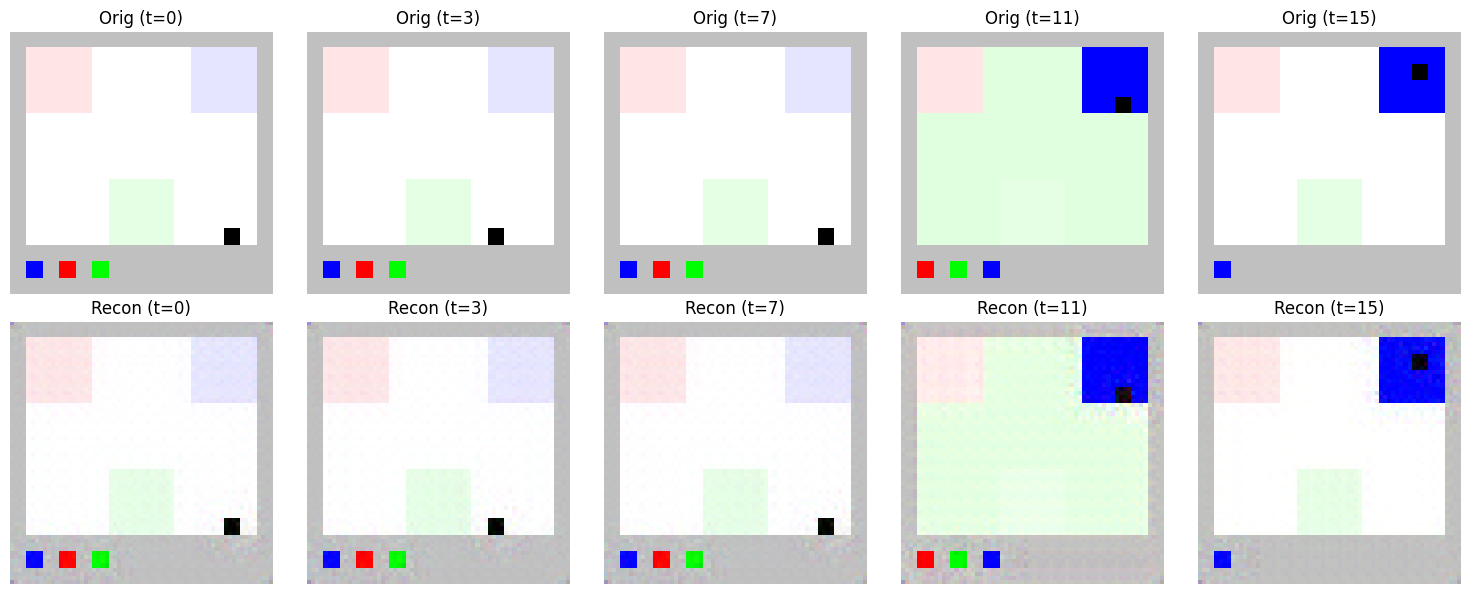

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def check_tokenizer_fidelity(tokenizer, video, num_frames=5):
    """
    Visualizes multiple frames to check reconstruction quality across time.
    Top Row: Original | Bottom Row: Reconstruction
    """
    device = next(tokenizer.parameters()).device
    video = video.to(device)
    
    # FIX: Ensure (1, C, T, H, W)
    if video.ndim == 4:
        video = video.unsqueeze(0)
        
    tokenizer.eval()
    with torch.no_grad():
        # Encode
        latents = tokenizer.tokenize(video) # (1, T, N, D)
        # Decode
        recon = tokenizer.decode(latents, height=64, width=64)
    tokenizer.train()

    # Calculate indices for frames to show (evenly spaced)
    T = video.shape[2]
    # If video is shorter than num_frames, just show all of them
    if T <= num_frames:
        indices = list(range(T))
    else:
        indices = np.linspace(0, T-1, num_frames, dtype=int)
    
    # Create grid: 2 Rows, N Columns
    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6))
    
    # Handle single frame case (matplotlib axes subtleties)
    if len(indices) == 1:
        axes = axes.reshape(2, 1)

    print(f"--- Stats for Frame {indices[0]} ---")
    
    for i, t_idx in enumerate(indices):
        # 1. Process Original
        # Un-normalize: [-1, 1] -> [0, 1]
        orig_img = (video[0, :, t_idx] + 1) / 2
        orig_img = orig_img.permute(1,2,0).cpu().clamp(0,1).numpy()
        
        # 2. Process Reconstruction
        recon_img = (recon[0, :, t_idx] + 1) / 2
        recon_img = recon_img.permute(1,2,0).cpu().clamp(0,1).numpy()
        
        # Print stats only for the first frame to keep logs clean
        if i == 0:
            print(f"Original range:      min={orig_img.min():.2f}, max={orig_img.max():.2f}")
            print(f"Reconstructed range: min={recon_img.min():.2f}, max={recon_img.max():.2f}")

        # 3. Plot Original (Top Row)
        axes[0, i].imshow(orig_img)
        axes[0, i].set_title(f"Orig (t={t_idx})")
        axes[0, i].axis('off')
        
        # 4. Plot Reconstruction (Bottom Row)
        axes[1, i].imshow(recon_img)
        axes[1, i].set_title(f"Recon (t={t_idx})")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage:
# sample = bc_ds[0]
# video = sample["video"].to(tk.device)   
# check_tokenizer_fidelity(tk, video)

sample = bc_ds[random.randint(0, len(bc_ds)-1)]
video = sample["video"].to(tk.device)   
check_tokenizer_fidelity(tk, video)  # use BC video for more variety

In [12]:
video[:,0,...].min(), video[:,0,...].max()

(tensor(-1., device='cuda:0'), tensor(1., device='cuda:0'))

In [13]:
## Tokenizer Training Loop ##

# first set lpips loss to 0
# tk.lpips_loss_weight = 0.0

# losses = []
# if True:
#     tok_tr.train()
#     # bc_tr.train()
#     print(f'{tk.training=}')
    
#     # while tok_tr.total_steps < 1e3:
#     for _ in range(100):
#         sample = bc_ds[random.randint(0, len(bc_ds)-1)]
#         video = sample["video"].to(tk.device)   
#         # Run the fixed sanity check
#         check_tokenizer_fidelity(tk, video)
#         # is the model in train or eval?
#         audit_gpu_memory()
#         losses.append(tok_tr())

# plot the losses
# import matplotlib.pyplot as plt
# import itertools
# flat_list = [
#     x
#     for xs in losses
#     for x in xs
# ]

# plt.plot(flat_list)
# plt.show()

Visualize the next frame

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def robust_autoregressive_eval(
    tokenizer,
    dynamics,
    video,             # (C,T,H,W)
    discrete_actions,  # (T, 1) or (T,)
    start_k=4,
    n_frames=4,        # Number of future frames to predict
    num_steps=8        # DDIM steps per frame
):
    # Get model device/dtype
    param = next(dynamics.parameters())
    device = param.device
    dtype = param.dtype
    
    # 1. Setup Video
    if video.ndim == 4: video = video.unsqueeze(0)
    video = video.to(device=device, dtype=dtype)
    B, C, T, H, W = video.shape

    # 2. Setup Actions
    if discrete_actions is not None:
        da = discrete_actions.to(device)
        if da.ndim == 1: da = da.unsqueeze(0).unsqueeze(-1)
        elif da.ndim == 2: da = da.unsqueeze(0)
    else:
        da = None

    # 3. Tokenize Initial History (0 to start_k-1)
    # curr_latents will act as our "growing history"
    curr_latents = tokenizer.tokenize(video[:, :, :start_k])
    if curr_latents.ndim == 4: curr_latents = curr_latents.unsqueeze(2) # Add view dim -> (B, T, V, N, D)
    
    # --- AUTOREGRESSIVE LOOP ---
    for i in range(n_frames):
        current_t = start_k + i
        
        # A. Setup Actions for this step (History + 1 new step)
        if da is not None:
            # Check if we run out of ground truth actions
            if current_t >= da.shape[1]: 
                # Pad with the last action if we go beyond GT
                last_act = da[:, -1:]
                da_input = torch.cat([da, last_act.repeat(1, current_t - da.shape[1] + 1, 1)], dim=1)
            else:
                da_input = da[:, :current_t+1]
        else:
            da_input = None

        # B. Init Noise for Next Frame
        n, d = curr_latents.shape[-2:]
        lat_next = torch.randn((B, 1, 1, n, d), device=device, dtype=dtype)

        # C. Flow Matching / Diffusion Schedule
        step_size = dynamics.max_steps // num_steps
        levels = torch.arange(0, dynamics.max_steps, step_size, device=device, dtype=torch.long)
        
        for level in levels:
            # Cat history + noisy next frame
            lat_in = torch.cat([curr_latents, lat_next], dim=1)

            # Signal levels
            sig_next = level.view(1, 1).repeat(B, 1)
            # Past frames get signal "max_steps-1" (clean data)
            sig_past = torch.full((B, lat_in.shape[1]-1), dynamics.max_steps - 1, device=device, dtype=torch.long)
            sig_full = torch.cat([sig_past, sig_next], dim=1)

            # Predict
            preds, _ = dynamics.forward(
                latents=lat_in,
                signal_levels=sig_full,
                step_sizes=step_size,
                discrete_actions=da_input,
                latent_is_noised=True,
                return_pred_only=True,
                return_intermediates=True,
                latent_has_view_dim=True,
            )
            
            # Safe Unpack
            if hasattr(preds, 'flow'): model_out = preds.flow
            elif isinstance(preds, tuple): model_out = preds[0]
            else: model_out = preds
            
            # Get just the last frame prediction
            model_out = model_out[:, -1:]

            # Flow Update
            if dynamics.pred_orig_latent:
                t_curr = level.float() / dynamics.max_steps
                t_curr = torch.clamp(t_curr, 0.0, 0.999).to(dtype)
                flow = (model_out - lat_next) / (1.0 - t_curr)
            else:
                flow = model_out
                
            dt = step_size / dynamics.max_steps
            lat_next = lat_next + flow * dt

        # D. Update History
        # Append the predicted latent to history
        curr_latents = torch.cat([curr_latents, lat_next], dim=1)

    # 4. Decode THE FULL SEQUENCE (Context + Prediction)
    # curr_latents shape: (B, Total_Frames, V, n, d)
    full_seq_lat = curr_latents[:, :, 0] # Remove view dim
    full_seq_lat = torch.clamp(full_seq_lat, -3.0, 3.0)
    
    full_recon_video = tokenizer.decode(full_seq_lat, height=H, width=W) # (B, C, Total_Frames, H, W)
    
    # 5. Get Full Ground Truth
    # Slice video to match the length of our reconstruction
    total_len = start_k + n_frames
    full_gt_video = video[:, :, :total_len]
    
    return {
        "pred_video": full_recon_video[0].float().cpu(), # (C, Total_T, H, W)
        "true_video": full_gt_video[0].float().cpu(),    # (C, Total_T, H, W)
        "start_k": start_k
    }

def viz_autoregressive(tokenizer, dynamics, video, discrete_actions, start_k=4, n_frames=4, num_steps=8):
    out = robust_autoregressive_eval(tokenizer, dynamics, video, discrete_actions, start_k, n_frames, num_steps)
    
    true_vid = out['true_video']
    pred_vid = out['pred_video']
    k = out['start_k']
    
    # Helper for image display
    def to_img(x): return (x + 1) / 2
    
    total_frames = true_vid.shape[1]
    
    fig, axes = plt.subplots(2, total_frames, figsize=(3 * total_frames, 5))
    if total_frames == 1: axes = axes[:, None]
    
    total_mse = 0.0
    count_mse = 0
    
    for t in range(total_frames):
        # Determine phase (Context vs Pred)
        is_context = t < k
        phase_str = "Context" if is_context else "Pred"
        
        # --- Top Row: Ground Truth ---
        img_true = to_img(true_vid[:, t]).permute(1,2,0).clamp(0,1).numpy()
        axes[0, t].imshow(img_true)
        axes[0, t].set_title(f"Orig t={t}")
        axes[0, t].axis("off")
        
        # --- Bottom Row: Reconstruction/Prediction ---
        img_pred = to_img(pred_vid[:, t]).permute(1,2,0).clamp(0,1).numpy()
        axes[1, t].imshow(img_pred)
        
        # Calculate MSE
        mse = F.mse_loss(true_vid[:, t], pred_vid[:, t]).item()
        
        # Only average MSE for the predicted frames
        if not is_context:
            total_mse += mse
            count_mse += 1
            title_color = "red" # Highlight predictions
        else:
            title_color = "black"

        axes[1, t].set_title(f"{phase_str} | MSE: {mse:.4f}", color=title_color)
        axes[1, t].axis("off")
        
        # Draw a vertical divider between context and prediction
        if t == k - 1 and t < total_frames - 1:
            # This draws a line on the figure canvas, a bit hacky but works for subplots
            # Alternatively, just rely on the text color change
            pass

    plt.suptitle(f"Full Sequence: Context (0-{k-1}) -> Autoregressive (Start t={k}, Steps={n_frames})")
    plt.tight_layout()
    plt.show()
    
    if count_mse > 0:
        print(f"Average MSE over {count_mse} predicted frames: {total_mse / count_mse:.5f}")

# # --- USAGE ---
# sample = bc_ds[0] 
# video = sample["video"].to(tk.device)            
# acts  = sample.get("discrete_actions").to(tk.device)

# viz_autoregressive(
#     tokenizer=tk,
#     dynamics=dynamics,
#     video=video,
#     discrete_actions=acts,
#     start_k=4,   # Context: Frames 0, 1, 2, 3
#     n_frames=4,  # Predict: Frames 4, 5, 6, 7
#     num_steps=8
# )

In [15]:
# show all 16 frames of the video in a grid
def plot_video_grid(video, rows=4, cols=4, title="Video Grid"):
    action_map = {0: 'none', 2: 'up', 1: 'down', 3: 'right', 4:'left'}

    v = canonicalize_cthw(get_video_from_sample(video))  # (C,T,H,W)
    C,T,H,W = v.shape
    assert rows * cols >= T, "Not enough grid cells for all frames"
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            axes[i,j].axis("off")
            if idx < T:
                img = v[:, idx].permute(1,2,0).cpu().numpy()
                axes[i,j].imshow(img)
                title=f"t={idx} Action: {action_map.get(sample['discrete_actions'][idx].item(), 'N/A')}"
                axes[i,j].set_title(title)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# plot_video_grid(sample, rows=4, cols=4, title="Sample Video from BC Dataset")

In [16]:
# import torch, numpy as np
# import torch.nn.functional as F

# @torch.no_grad()
# def eval_open_loop_k_steps(tokenizer, dynamics, video, k=4, H=8, actions=None, rewards=None):
#     """
#     Predict H future frames given a rolling window of the last k frames.
#     Keeps the context fixed at length k (so model input is always k+1).
#     Returns per-step MSE and mean MSE.
#     """
#     device = next(dynamics.parameters()).device

#     # standardize to (1,C,T,H,W)
#     if video.ndim == 4:
#         video = video.unsqueeze(0)
#     elif video.ndim != 5:
#         raise ValueError(f"video must be (C,T,H,W) or (1,C,T,H,W); got {tuple(video.shape)}")
#     video = video.to(device)
#     B,C,T,VH,VW = video.shape
#     if B != 1: raise ValueError("Only B=1 supported for this eval.")
#     if T <= k: raise ValueError(f"Need T > k (T={T}, k={k}).")
#     if H > (T - k): H = T - k  # clip horizon if needed

#     # optional A/R to (1,T,...) with right padding if short
#     def _prep_opt(x, need_len):
#         if x is None: return None
#         x = x.to(device)
#         if x.ndim == 1: x = x.unsqueeze(0)            # (1,T)
#         elif x.ndim == 2 and x.shape[0] != 1: x = x.unsqueeze(0)  # (1,T,NA?)
#         if x.shape[1] < need_len:
#             pad = torch.zeros((x.shape[0], need_len - x.shape[1], *x.shape[2:]),
#                               dtype=x.dtype, device=x.device)
#             x = torch.cat([x, pad], dim=1)
#         return x

#     actions = _prep_opt(actions, need_len=T)
#     rewards = _prep_opt(rewards, need_len=T)

#     # tokenize initial history (first k)
#     lat_past = tokenizer.tokenize(video[:, :, :k]).unsqueeze(2)  # (1,k,1,n,d)
#     n, d = lat_past.shape[-2], lat_past.shape[-1]

#     per_step_mse = []

#     for step in range(H):
#         # always condition on last k -> input length is k+1
#         lat_slot = torch.randn((1,1,1,n,d), device=device)
#         lat_in = torch.cat([lat_past, lat_slot], dim=1)          # (1,k+1,1,n,d)

#         # align A/R to last k (then pad one)
#         da = None
#         if actions is not None:
#             a_k = actions[:, step:step+k]                         # (1,k,NA?) or (1,k)
#             pad = torch.zeros_like(a_k[:, :1])                    # (1,1,...)
#             da = torch.cat([a_k, pad], dim=1)                     # (1,k+1,...)

#         rw = None
#         if rewards is not None:
#             r_k = rewards[:, step:step+k]                         # (1,k)
#             rw  = torch.cat([r_k, torch.zeros_like(r_k[:, :1])], dim=1)  # (1,k+1)

#         # inference schedule for exactly k+1 tokens
#         step_size = torch.tensor(1, device=device)
#         signal_levels = torch.full((1, k+1), dynamics.max_steps - 1,
#                                    dtype=torch.long, device=device)

#         # predict next latent (one denoise step)
#         pred, _ = dynamics.forward(
#             latents=lat_in,
#             signal_levels=signal_levels,
#             step_sizes=step_size,
#             rewards=rw,
#             discrete_actions=da,
#             latent_is_noised=True,
#             return_pred_only=True,
#             return_intermediates=True,
#             latent_has_view_dim=True,
#         )
#         if isinstance(pred, tuple): pred = pred[0]                # strip proprio if present
#         pred_next_lat = pred[:, -1, 0]                            # (1,n,d)

#         # decode and compare to ground truth at t = k+step
#         pred_frame = tokenizer.decode(pred_next_lat, height=VH, width=VW)[0, :, 0]
#         true_frame = video[0, :, k + step]
#         per_step_mse.append(F.mse_loss(pred_frame, true_frame).item())

#         # roll history window: drop oldest, append GT next latent
#         gt_next_lat = tokenizer.tokenize(video[:, :, k + step : k + step + 1])  # (1,1,n,d)
#         lat_past = torch.cat([lat_past[:, 1:], gt_next_lat.unsqueeze(2)], dim=1)  # keep length k

#     return {
#         "per_step_mse": np.array(per_step_mse, dtype=np.float32),
#         "mean_mse": float(np.mean(per_step_mse)),
#         "k": k,
#         "H": H,
#         "T": int(T),
#     }


# import torch, numpy as np
# import matplotlib.pyplot as plt

# sample = bc_ds[0]
# video = sample["video"]            # (C,T,H,W)
# acts  = sample.get("discrete_actions")
# rews  = sample.get("rewards")

# print("video shape:", tuple(video.shape))  # helpful debug
# k, H = 4, 8

# out = eval_open_loop_k_steps(
#     tokenizer=tk,
#     dynamics=dynamics,
#     video=video,
#     k=k,
#     H=H,                 # will auto-clip to T-k if needed
#     actions=acts,
#     rewards=rews
# )

# print("T, k, (possibly clipped) H:", out["T"], out["k"], out["H"])
# print("Per-step MSE:", out["per_step_mse"], "Mean:", out["mean_mse"])


# # quick plot
# plt.figure(figsize=(5,3))
# plt.plot(range(1, H+1), out["per_step_mse"], marker="o")
# plt.xlabel("Prediction step (t = k + step)")
# plt.ylabel("MSE")
# plt.title(f"Open-loop {H}-step MSE (k={k})")
# plt.tight_layout(); plt.show()

In [17]:
# --- EVAL HARNESS FOR PINPAD + DYNAMICS ---

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

@torch.no_grad()
def run_env_eval(
    env,
    dynamics,                # DynamicsWorldModel (already paired with tokenizer)
    tokenizer=None,          # VideoTokenizer or None
    episodes=5,
    max_steps=64,            # steps per episode (caps rollout inside interact_with_env)
    env_is_vectorized=False,
    show_first_k=8,          # how many frames to visualize
    show=True                # set False for headless metric-only
):
    device = next(dynamics.parameters()).device

    # put model in eval for stable behavior
    was_training = dynamics.training
    dynamics.eval()

    ep_stats = []
    visuals = []  # optional (video, recon) pairs for first few episodes

    for ep in range(episodes):
        exp = dynamics.interact_with_env(
            env,
            max_timesteps=max_steps,
            env_is_vectorized=env_is_vectorized,
            use_time_cache=True,
            store_agent_embed=False,
            store_old_action_unembeds=False
        )

        # rewards: (B, T) where B=1 here
        rewards = exp.rewards.squeeze(0) if exp.rewards is not None else torch.zeros(0, device=device)
        total_r = rewards.sum().item()
        ep_len  = rewards.numel()
        # PinPad marks success with +10 reward on success step
        success = (rewards.max().item() >= 9.99) if rewards.numel() > 0 else False

        stat = dict(reward=total_r, length=ep_len, success=bool(success))
        ep_stats.append(stat)

        if show and exp.video is not None and tokenizer is not None:
            # exp.video: (B,C,T,H,W); exp.latents: (B,T, [V=1], N, D) or (B,T,N,D)
            video = exp.video[0].detach().cpu()                      # (C,T,H,W)
            latents = exp.latents.to(device)
            # decode latents back to video for comparison
            C, T, H, W = video.shape
            lat_for_dec = latents
            if lat_for_dec.ndim == 5:  # (B,T,1,N,D) -> (B,T,N,D)
                lat_for_dec = lat_for_dec[..., 0, :, :]
            recon = tokenizer.decode(lat_for_dec, height=H, width=W)[0].detach().cpu()  # (C,T,H,W)
            visuals.append((video, recon))

            # visualize a few frames inline
            t_show = min(T, show_first_k)
            fig, axes = plt.subplots(2, t_show, figsize=(3*t_show, 6))
            for i in range(t_show):
                axes[0, i].imshow(video[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[0, i].set_title(f"ep {ep} | orig t={i}")
                axes[0, i].axis("off")

                axes[1, i].imshow(recon[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[1, i].set_title(f"ep {ep} | recon t={i}")
                axes[1, i].axis("off")

            fig.suptitle(f"Reward={total_r:.2f} | Len={ep_len} | Success={success}")
            plt.tight_layout()
            display(fig)
            plt.close(fig)

    # restore training state
    dynamics.train(was_training)

    # aggregate metrics
    rewards = [s["reward"] for s in ep_stats]
    lengths = [s["length"] for s in ep_stats]
    successes = [s["success"] for s in ep_stats]

    summary = dict(
        episodes=episodes,
        avg_reward=float(np.mean(rewards)) if rewards else 0.0,
        avg_length=float(np.mean(lengths)) if lengths else 0.0,
        success_rate=float(np.mean(successes)) if successes else 0.0,
        per_episode=ep_stats,
        visuals=visuals,  # list of (video, recon), only when show=True & tokenizer provided
        d_actions=exp.actions[0].cpu() if exp.actions is not None else None,
    )

    print(
        f"[EVAL] episodes={episodes} | "
        f"avg_reward={summary['avg_reward']:.3f} | "
        f"avg_len={summary['avg_length']:.1f} | "
        f"success_rate={summary['success_rate']*100:.1f}%"
    )
    return summary


In [18]:
# Convert action indices to (dx, dy) movements for gut check

pinpad_actions = [(0, 0), (0, 2), (0, -2), (2, 0), (-2, 0)]
# for da in summary['d_actions'][0, :10]: 
for da in sample['discrete_actions']:
    print(f"Action taken: {pinpad_actions[da.item()]}")

Action taken: (2, 0)
Action taken: (2, 0)
Action taken: (-2, 0)
Action taken: (2, 0)
Action taken: (0, 2)
Action taken: (-2, 0)
Action taken: (2, 0)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, 0)
Action taken: (0, -2)


In [19]:
bc_ds[0]['rewards']

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [21]:
# SimTrainer class definition removed. Using imported version.
# See dreamer4/trainers.py
import torch.nn as nn

dynamics = DynamicsWorldModel(
    video_tokenizer=tk,
    dim=dim,
    dim_latent=dim_latent,
    max_steps=64,
    num_tasks=1,
    num_latent_tokens=num_latent_tokens,          # match tokenizer
    num_spatial_tokens=num_spatial_tokens,         # was 2 (too tiny), then 8 not big enough to track movement
    depth=6, # dynamics_depth,                      # was default 4
    time_block_every=time_block_every,           # was 4
    pred_orig_latent=True,
    num_discrete_actions=env.action_space.n,
    attn_heads=4,
    attn_dim_head=32,
    prob_no_shortcut_train=0.99, #0.4,   # give shortcut some presence
    num_residual_streams=1,
    use_time_rnn = use_time_rnn,
    multi_token_pred_len=8,
).to(device)

# 1. Patch the Latent Prediction Head (Fixes Flow Loss)
# We insert LayerNorm to squash the 452.0 input down to ~1.0
if not isinstance(dynamics.to_latent_pred[0], nn.LayerNorm):
    print("Patching Latent Prediction Head with LayerNorm...")
    dynamics.to_latent_pred = nn.Sequential(
        nn.LayerNorm(dim),
        dynamics.to_latent_pred
    ).to(device)
else:
    print("Latent Head already patched.")

if not isinstance(dynamics.policy_head[0], nn.LayerNorm):
    print("Patching Policy Head Head with LayerNorm...")
    dynamics.policy_head = nn.Sequential(
        nn.LayerNorm(dim),
        dynamics.policy_head
    ).to(device)

if not isinstance(dynamics.value_head[0], nn.LayerNorm):
    print("Patching Value Head with LayerNorm...")
    dynamics.value_head = nn.Sequential(
        nn.LayerNorm(dim),
        dynamics.value_head
    ).to(device)

# Updated SimTrainer instantiation (removed video_tokenizer argument)
sim_tr = SimTrainer(dynamics, accelerate_kwargs=accelerate_kwargs)

# sim_tr(env, num_episodes=1, max_env_steps=100)
# sim_tr.eval_episodes(env, show=True, max_steps=21, max_time_to_show=21)


Patching Latent Prediction Head with LayerNorm...


In [22]:
# 1. Setup Optimizer for the WHOLE model (not just heads)
dynamics_optim = torch.optim.AdamW(dynamics.parameters(), lr=3e-4)



In [ ]:
# 1. Setup
from tqdm import tqdm
print("Training World Model Physics (Reconstruction)...")
dynamics.train()

# Use your existing bc_ds dataset
dl = DataLoader(bc_ds, batch_size=16, shuffle=True, drop_last=True)
epochs = 100 

for epoch in range(epochs):
    epoch_loss = 0
    with tqdm(dl, desc=f"Dynamics Epoch {epoch+1}") as pbar:
        for batch_idx, batch in enumerate(pbar):
            # Prepare Data
            video = batch['video']
            actions = batch['discrete_actions']
            rewards = batch.get('rewards', None) # If your dataset has rewards
            
            # Tokenize
            with torch.no_grad():
                if video.dtype == torch.uint8:
                    video = video.float() / 255.0
                    video = video * 2.0 - 1.0
                target_dtype = next(tk.parameters()).dtype 
                video = video.to(device, dtype=target_dtype)
                latents = tk.tokenize(video)

            actions = actions.to(device)
            
            # [FIX 2] Clamp Rewards to prevent "Value Head Death" scenario
            # Even though this trains the Reward Predictor (not Value Head), 
            # outliers can still destabilize the shared features.
            if rewards is not None:
                rewards = rewards.to(device).clamp(-20, 20)

            # --- DYNAMICS UPDATE ---
            loss, all_losses = dynamics(
                latents=latents,
                discrete_actions=actions,
                rewards=rewards,
                return_pred_only=False, 
                latent_is_noised=False,
                return_all_losses=True,
            )
            
            if isinstance(loss, tuple): loss = loss[0]

            # Update
            dynamics_optim.zero_grad()
            loss.backward()
            
            # Clip grads (Safe)
            torch.nn.utils.clip_grad_norm_(dynamics.parameters(), 0.5)
            
            dynamics_optim.step()
            
            epoch_loss += all_losses.flow.item()

            pbar.set_postfix(
                flow=f"{all_losses.flow.item():.4f}",
                rew=f"{all_losses.rewards.mean().item():.4f}",
                act=f"{all_losses.discrete_actions.mean().item():.4f}"
            )

    # [FIX 1] Visualization INSIDE the loop
    # Check progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"--- Epoch {epoch+1} Evaluation ---")
        
        # Pick a random sample for variety
        sample = bc_ds[random.randint(0, len(bc_ds)-1)]
        video_sample = sample["video"].to(tk.device)
        acts_sample  = sample.get("discrete_actions").to(tk.device)
        
        viz_autoregressive(
            tokenizer=tk,
            dynamics=dynamics,
            video=video_sample,
            discrete_actions=acts_sample,
            start_k=4,   
            n_frames=8, # See if it holds up for 8 frames
            num_steps=8
        )
        
        # Put back in train mode!
        dynamics.train() 

print("Physics Engine Trained.")

Training World Model Physics (Reconstruction)...


TypeError: 'module' object is not callable

In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def get_action_probs(dynamics, video):
    """
    Returns the probability distribution over discrete actions.
    Correctly handles ActionEmbedder's parameter-based projection.
    Returns: (Batch, Time, Num_Actions)
    """
    dynamics.eval()
    
    # 1. Tokenize
    if video.ndim == 4: video = video.unsqueeze(0)
    latents = dynamics.video_tokenizer.tokenize(video)
    
    # 2. Dynamics Forward (Get Agent Embeddings)
    # We pass actions=None so it runs in generation mode (using past context)
    _, (embeds, _) = dynamics(
        latents=latents,
        return_intermediates=True,
        return_pred_only=True
    )
    
    # 3. Get Agent Embeddings
    # Shape: (B, T, Agents, Dim) -> (B, T, Dim)
    # Assuming 1 agent
    if embeds.agent.ndim == 4:
        agent_embeds = embeds.agent.squeeze(2)
    else:
        agent_embeds = embeds.agent
    
    # 4. Policy Head Projection (MLP)
    policy_embed = dynamics.policy_head(agent_embeds)
    
    # 5. [CORRECTED] Extract Logits using the Embedder
    # The embedder has a specific method 'unembed' that handles the projection matrix
    discrete_logits, _ = dynamics.action_embedder.unembed(
        policy_embed,
        pred_head_index=0 # We only care about the immediate next action
    )
    
    # If multiple discrete action types exist, it returns a tuple or split tensor.
    # For a standard gym env, we usually want the first/only one.
    if isinstance(discrete_logits, (tuple, list)):
        discrete_logits = discrete_logits[0]
        
    # 6. Softmax
    probs = F.softmax(discrete_logits, dim=-1)
    
    return probs

import matplotlib.pyplot as plt
import numpy as np

def viz_actor_confidence(dynamics, dataset, idx=0):
    sample = dataset[idx]
    video = sample['video'].to(dynamics.device)
    true_actions = sample['discrete_actions'].cpu().numpy().flatten()
    
    # Get Probabilities
    probs = get_action_probs(dynamics, video)[0].cpu().numpy() # (Time, Num_Actions)
    
    T, N = probs.shape
    time_steps = np.arange(T)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Heatmap
    # Transpose so Time is X-axis
    im = ax.imshow(probs.T, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
    
    # Overlay Ground Truth
    # We plot the Expert's choice as a red X
    # Note: Action at step T usually predicts state T+1 or is taken at state T.
    # Check alignment: if the X's lag behind the blue spots, shift by +1.
    ax.scatter(time_steps, true_actions[:T], color='red', marker='x', s=100, linewidth=2, label='Expert Action')
    
    ax.set_title(f"Actor Policy Distribution (Sample {idx})")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Action Class")
    ax.set_yticks(range(N))
    ax.legend(loc='upper right')
    
    fig.colorbar(im, ax=ax, label="P(action|state)")
    plt.tight_layout()
    plt.show()

# Run it on a random sample
import random
idx = random.randint(0, len(bc_ds)-1)
viz_actor_confidence(dynamics, bc_ds, idx)

In [ ]:
# 1. Freeze the Transformer (Backbone)
for p in dynamics.parameters(): 
    p.requires_grad = False

# 2. Unfreeze BOTH Heads
for p in dynamics.policy_head.parameters(): 
    p.requires_grad = True
    
for p in dynamics.value_head.parameters(): 
    p.requires_grad = True

# 3. Unfreeze Action/Reward Embeddings (Critical for the heads to work)
if hasattr(dynamics, 'action_embedder'):
    for p in dynamics.action_embedder.parameters(): p.requires_grad = True
if hasattr(dynamics, 'reward_encoder'):
    # Usually reward encoder is fixed, but let's check your specific class
    pass

print("Backbone Frozen. Heads Unfrozen.")

def train_heads_offline(self, dataset, epochs=5):
    epochs = default(epochs, self.epochs)
    
    if self.video_tokenizer is None:
        self.video_tokenizer = getattr(self.unwrapped_model, 'video_tokenizer', None)
    
    dl = DataLoader(dataset, batch_size=self.batch_size, shuffle=True, drop_last=True)
    dl = self.accelerator.prepare(dl)

    print(f"Starting Head Warmup (Policy + Value) for {epochs} epochs...")

    for epoch in range(epochs):
        with tqdm(dl, desc=f"Warmup Epoch {epoch+1}/{epochs}") as pbar:
            for batch in pbar:
                # 1. Data
                video = batch['video']
                actions = batch['discrete_actions']
                rewards = batch.get('rewards', None) 

                with torch.no_grad():
                    if video.dtype == torch.uint8:
                        video = video.float() / 255.0
                        video = video * 2.0 - 1.0
                    
                    target_dtype = next(self.video_tokenizer.parameters()).dtype
                    video = video.to(self.device, dtype=target_dtype)
                    latents = self.video_tokenizer.tokenize(video)

                # 2. Forward (Get Embeddings)
                with torch.no_grad():
                    _, (embeds, _) = self.model(
                        latents=latents,
                        discrete_actions=actions, 
                        return_intermediates=True,
                        return_pred_only=True 
                    )
                    agent_embeds = embeds.agent # Shape: (B, T, 1, D)

                # 3. Policy Loss (Behavior Cloning)
                policy_logits = self.model.policy_head(agent_embeds)
                
                # log_probs helper handles the extra dimensions gracefully usually, 
                # but if it fails, we might need to squeeze agent_embeds first.
                # For now, let's trust it works or squeeze if needed:
                if agent_embeds.ndim == 4:
                    policy_logits = policy_logits.squeeze(2) # Remove agent dim (B, T, 1, D) -> (B, T, D)

                log_probs = self.model.action_embedder.log_probs(
                    policy_logits, # Passed as logits, helper will softmax it
                    discrete_targets=actions,
                    pred_head_index=0,
                ) 
                
                # Handle tuple return
                if isinstance(log_probs, tuple):
                    log_probs = log_probs[0]
                    
                policy_loss = -log_probs.mean()

                # 4. Value Loss (Reward Prediction)
                value_loss = torch.tensor(0., device=self.device)
                
                if rewards is not None:
                    rewards = rewards.to(self.device).clamp(-20, 20)
                    
                    # value_bins Shape: (B, T, 1, N_bins) -> because input had agent dim
                    value_bins = self.model.value_head(agent_embeds)
                    
                    # Target Encoding
                    target_bins = self.model.reward_encoder(rewards) 
                    
                    # [FIX] Robust Rearrange
                    # Uses '...' to absorb the agent dimension (whether it exists or not)
                    # Flattens everything into (Batch * Time * Agents, Bins)
                    value_bins_flat = rearrange(value_bins, 'b t ... n -> (b t ...) n')
                    target_bins_flat = rearrange(target_bins, 'b t ... n -> (b t ...) n')
                    
                    value_loss = F.cross_entropy(value_bins_flat, target_bins_flat)

                # 5. Updates
                total_loss = policy_loss + value_loss

                self.accelerator.backward(total_loss)
                
                if exists(self.max_grad_norm):
                    head_params = [
                        *self.model.policy_head.parameters(),
                        *self.model.value_head.parameters()
                    ]
                    self.accelerator.clip_grad_norm_(head_params, self.max_grad_norm)
                
                self.policy_head_optim.step()
                self.value_head_optim.step()
                
                self.policy_head_optim.zero_grad()
                self.value_head_optim.zero_grad()
                
                pbar.set_postfix(pol=policy_loss.item(), val=value_loss.item())

    print("Head Warmup Complete.")

# Monkey Patch
import types
from einops import rearrange
import torch.nn.functional as F

sim_tr.train_heads_offline = types.MethodType(train_heads_offline, sim_tr)

# Run
sim_tr.train_heads_offline(bc_ds, epochs=5)

In [ ]:
# Unfreeze everything
for p in dynamics.parameters(): p.requires_grad = True
print("All systems go. Ready for Online PPO.")

In [ ]:


sample = bc_ds[random.randint(0, len(bc_ds)-1)]
# ... (your existing data loading code) ...
video = sample["video"].to(tk.device)
acts  = sample.get("discrete_actions").to(tk.device)
# Visualize next 4 frames
viz_autoregressive(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    start_k=4,   # Start predicting from frame 4
    n_frames=4,  # Predict 4, 5, 6, 7
    num_steps=8
)
print("Physics Engine Trained.")

for k,v in all_losses._asdict().items():
    print(k,f'{v}')

In [ ]:
train_eps=100
dynamics.train()
# experience = dynamics.interact_with_env(env) # one episode
# sim_tr.learn(experience)


sim_tr(env, num_episodes=train_eps, max_env_steps=50)


In [ ]:

sim_tr.eval_episodes(env, show=True, max_steps=50, max_time_to_show=21)



In [ ]:

sample = bc_ds[random.randint(0, len(bc_ds)-1)]
# ... (your existing data loading code) ...
video = sample["video"].to(tk.device)
acts  = sample.get("discrete_actions").to(tk.device)
# Visualize next 4 frames
viz_autoregressive(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    start_k=1,   # Start predicting from frame 4
    n_frames=4,  # Predict 4, 5, 6, 7
    num_steps=8
)

In [ ]:

"""
Trains the policy head using Behavior Cloning on an existing dataset.
Useful for pre-training before starting online RL.
"""
epochs = 10; train_eps=10
dynamics.train()
# experience = dynamics.interact_with_env(env) # one episode
# sim_tr.learn(experience)

sim_tr.train_from_dataset(bc_ds, epochs)
sim_tr(env, num_episodes=train_eps, max_env_steps=100)
# sim_tr.eval_episodes(env, show=True, max_steps=21, max_time_to_show=21)

sample = bc_ds[random.randint(0, len(bc_ds)-1)]
# ... (your existing data loading code) ...
video = sample["video"].to(tk.device)
acts  = sample.get("discrete_actions").to(tk.device)

# Visualize next 4 frames
viz_autoregressive(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    start_k=1,   # Start predicting from frame 4
    n_frames=4,  # Predict 4, 5, 6, 7
    num_steps=8
)



In [ ]:
# plot the losses
import matplotlib.pyplot as plt
import itertools
flat_list = [
    x
    for xs in losses
    for x in xs
]

plt.plot(flat_list)
plt.show()

In [ ]:
if DO_PLOT:=True:
    # quick plot
    plt.figure(figsize=(5,3))
    plt.plot(range(1, H+1), mets["per_step_mse"], marker="o")
    plt.xlabel("Prediction step (t = k + step)")
    plt.ylabel("MSE")
    plt.title(f"Open-loop {H}-step MSE (k={k})")
    plt.tight_layout(); plt.show(block=False)

    # assuming you already have:
    # env          = PinPad(...) or your wrapped env (normalizes to [0,1])
    # tokenizer    = VideoTokenizer(...); tokenizer.eval()
    # dynamics     = DynamicsWorldModel(..., video_tokenizer=tokenizer, ...); dynamics.eval()
    # (optionally load weights for both)


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()